In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
from pathlib import Path
import networkx as nx
import numpy as np
import logging

logging.basicConfig(level=logging.WARNING)

In [12]:
YEAR = 2019

BASE_PATH     = "data"
DENMARK_PATH  = f"{BASE_PATH}/Denmark_En_DH"
GERMANY_PATH  = f"{BASE_PATH}/Germany_En_DH"
NORWAY_PATH   = f"{BASE_PATH}/Norway_En_DH"
SWEDEN_PATH   = f"{BASE_PATH}/Sweden_En_DH"
LOAD_PATH     = f"{BASE_PATH}/Load/time_series_60min_singleindex.csv"

In [13]:
def annualize(capex, r, lifetime):
    crf = (r * (1 + r)**lifetime) / ((1 + r)**lifetime - 1)
    return capex * crf

r = 0.07

# Solar
CAPITAL_COST_SOLAR_DE = float(annualize(700_000,   r, lifetime=25))
CAPITAL_COST_SOLAR_DK = float(annualize(772_000,   r, lifetime=25))
CAPITAL_COST_SOLAR_SE = float(annualize(861_000,   r, lifetime=25))

# Wind onshore
CAPITAL_COST_WIND_ON_DE = float(annualize(1_900_000, r, lifetime=25))
CAPITAL_COST_WIND_ON_DK = float(annualize(1_950_000, r, lifetime=25))
CAPITAL_COST_WIND_ON_SE = float(annualize(1_400_000, r, lifetime=25))
CAPITAL_COST_WIND_ON_NO = float(annualize(1_400_000, r, lifetime=25))

# Wind offshore
CAPITAL_COST_WIND_OFF_DE = float(annualize(4_150_000, r, lifetime=25))
CAPITAL_COST_WIND_OFF_DK = float(annualize(2_900_000, r, lifetime=25))

# Gas DK
CAPITAL_COST_GAS_DK = float(annualize(1_300_000, r, lifetime=25))

# Marginal costs DK renewables
MARGINAL_COST_SOLAR_DK   = 0
MARGINAL_COST_WIND_ON_DK = 0
MARGINAL_COST_WIND_OFF_DK = 0
MARGINAL_COST_GAS_DK     = 43.18 / 0.47

In [14]:
snapshots = pd.date_range(
    start=f"{YEAR}-01-01 00:00:00",
    end=f"{YEAR}-12-31 23:00:00",
    freq="h"
)

pv       = pd.read_csv(f"{DENMARK_PATH}/ninja-pv-country-DK-national-merra2.csv", skiprows=3)
wind_on  = pd.read_csv(f"{DENMARK_PATH}/ninja-wind-country-DK-current_onshore-merra2.csv", skiprows=3)
wind_off = pd.read_csv(f"{DENMARK_PATH}/ninja-wind-country-DK-current_offshore-merra2.csv", skiprows=3)
load_df  = pd.read_csv(LOAD_PATH)

pv["time"]       = pd.to_datetime(pv["time"], utc=True)
wind_on["time"]  = pd.to_datetime(wind_on["time"], utc=True)
wind_off["time"] = pd.to_datetime(wind_off["time"], utc=True)
load_df["utc_timestamp"] = pd.to_datetime(load_df["utc_timestamp"], utc=True)

pv       = pv.set_index("time")
wind_on  = wind_on.set_index("time")
wind_off = wind_off.set_index("time")
load_df  = load_df.set_index("utc_timestamp")

pv.index       = pv.index.tz_convert(None)
wind_on.index  = wind_on.index.tz_convert(None)
wind_off.index = wind_off.index.tz_convert(None)
load_df.index  = load_df.index.tz_convert(None)

pv       = pv.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
wind_on  = wind_on.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
wind_off = wind_off.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]
load_df  = load_df.loc[f"{YEAR}-01-01":f"{YEAR}-12-31 23:00:00"]

data = pd.DataFrame(index=snapshots)
data["load"]        = load_df["DK_load_actual_entsoe_transparency"]
data["solar_cf"]    = pv["NATIONAL"]
data["wind_on_cf"]  = wind_on["NATIONAL"]
data["wind_off_cf"] = wind_off["NATIONAL"]

data = data.reindex(snapshots).interpolate(method="time").ffill().bfill()

print("DK NaN check:", data.isna().sum().sum())
print(data.head())

DK NaN check: 0
                        load  solar_cf  wind_on_cf  wind_off_cf
2019-01-01 00:00:00  3186.04       0.0    0.805840     0.896970
2019-01-01 01:00:00  3070.07       0.0    0.839171     0.916942
2019-01-01 02:00:00  2966.19       0.0    0.861352     0.927392
2019-01-01 03:00:00  2933.48       0.0    0.882439     0.948853
2019-01-01 04:00:00  2940.64       0.0    0.903024     0.960074


In [15]:
def read_load_energycharts(path, year):
    df = pd.read_csv(path, skiprows=[1])
    df.columns = df.columns.str.strip()
    df = df.rename(columns={df.columns[0]: "time"})
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_convert(None)
    df = df.set_index("time")
    df = df.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]
    load = df["Load"].astype(float)
    if len(load) > 9000:
        load = load.resample("h").mean()
    load = load[~load.index.duplicated(keep="first")]
    load = load.resample("h").mean().interpolate(method="time")
    return load


def read_country_data(pv_path, wind_on_path, wind_off_path, load_path, year):
    pv_c       = pd.read_csv(pv_path, skiprows=3)
    wind_on_c  = pd.read_csv(wind_on_path, skiprows=3)
    wind_off_c = pd.read_csv(wind_off_path, skiprows=3)

    for df in [pv_c, wind_on_c, wind_off_c]:
        df["time"] = pd.to_datetime(df["time"], utc=True)

    pv_c       = pv_c.set_index("time")
    wind_on_c  = wind_on_c.set_index("time")
    wind_off_c = wind_off_c.set_index("time")

    pv_c.index       = pv_c.index.tz_convert(None)
    wind_on_c.index  = wind_on_c.index.tz_convert(None)
    wind_off_c.index = wind_off_c.index.tz_convert(None)

    pv_c       = pv_c.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]
    wind_on_c  = wind_on_c.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]
    wind_off_c = wind_off_c.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]

    d = pd.DataFrame(index=snapshots)
    d["load"]        = read_load_energycharts(load_path, year).reindex(snapshots)
    d["solar_cf"]    = pv_c["NATIONAL"].astype(float)
    d["wind_on_cf"]  = wind_on_c["NATIONAL"].astype(float)
    d["wind_off_cf"] = wind_off_c["NATIONAL"].astype(float)

    return d.reindex(snapshots).interpolate(method="time").ffill().bfill()


data_de = read_country_data(
    pv_path       = f"{GERMANY_PATH}/ninja-pv-country-DE-national-merra2.csv",
    wind_on_path  = f"{GERMANY_PATH}/ninja-wind-country-DE-current_onshore-merra2.csv",
    wind_off_path = f"{GERMANY_PATH}/ninja-wind-country-DE-current_offshore-merra2.csv",
    load_path     = f"{GERMANY_PATH}/energy-charts_Public_net_electricity_generation_in_Germany_in_2019.csv",
    year=YEAR
)

data_no = read_country_data(
    pv_path       = f"{NORWAY_PATH}/ninja-pv-country-NO-national-merra2.csv",
    wind_on_path  = f"{NORWAY_PATH}/ninja-wind-country-NO-current_onshore-merra2.csv",
    wind_off_path = f"{NORWAY_PATH}/ninja-wind-country-NO-current_offshore-merra2.csv",
    load_path     = f"{NORWAY_PATH}/energy-charts_Public_net_electricity_generation_in_Norway_in_2019.csv",
    year=YEAR
)

data_se = read_country_data(
    pv_path       = f"{SWEDEN_PATH}/ninja-pv-country-SE-national-merra2.csv",
    wind_on_path  = f"{SWEDEN_PATH}/ninja-wind-country-SE-current_onshore-merra2.csv",
    wind_off_path = f"{SWEDEN_PATH}/ninja-wind-country-SE-current_offshore-merra2.csv",
    load_path     = f"{SWEDEN_PATH}/energy-charts_Public_net_electricity_generation_in_Sweden_in_2019.csv",
    year=YEAR
)

print("DE:", data_de.shape, data_de.isna().sum().sum())
print("NO:", data_no.shape, data_no.isna().sum().sum())
print("SE:", data_se.shape, data_se.isna().sum().sum())

DE: (8760, 4) 0
NO: (8760, 4) 0
SE: (8760, 4) 0


In [16]:
def read_hydro(path, hydro_cols, p_nom, year, resample_hourly=False):
    col_names = pd.read_csv(path, nrows=0).columns.tolist()
    df = pd.read_csv(path, skiprows=2, header=None, names=col_names,
                     parse_dates=[0], index_col=0)
    df.index = pd.to_datetime(df.index, utc=True).tz_convert(None)
    df = df.loc[f"{year}-01-01":f"{year}-12-31 23:00:00"]

    hydro_total = df[hydro_cols].sum(axis=1)
    if resample_hourly:
        hydro_total = hydro_total.resample("h").mean()

    d = pd.DataFrame(index=snapshots)
    d["hydro_cf"] = (hydro_total / p_nom).clip(0, 1)
    return d.reindex(snapshots).interpolate(method="time").ffill().bfill()


hydro_de = read_hydro(
    f"{GERMANY_PATH}/energy-charts_Public_net_electricity_generation_in_Germany_in_2019.csv",
    hydro_cols=["Hydro Run-of-River", "Hydro water reservoir", "Hydro pumped storage"],
    p_nom=5900, year=YEAR, resample_hourly=True
)

hydro_no_ror = read_hydro(
    f"{NORWAY_PATH}/energy-charts_Public_net_electricity_generation_in_Norway_in_2019.csv",
    hydro_cols=["Hydro Run of River"],
    p_nom=6300, year=YEAR
)

hydro_no_res = read_hydro(
    f"{NORWAY_PATH}/energy-charts_Public_net_electricity_generation_in_Norway_in_2019.csv",
    hydro_cols=["Hydro water reservoir"],
    p_nom=27530, year=YEAR
)

hydro_se = read_hydro(
    f"{SWEDEN_PATH}/energy-charts_Public_net_electricity_generation_in_Sweden_in_2019.csv",
    hydro_cols=["Hydro water reservoir"],
    p_nom=16320, year=YEAR
)

print("Hydro DE:", hydro_de.shape)
print("Hydro NO RoR:", hydro_no_ror.shape)
print("Hydro NO Res:", hydro_no_res.shape)
print("Hydro SE:", hydro_se.shape)

Hydro DE: (8760, 1)
Hydro NO RoR: (8760, 1)
Hydro NO Res: (8760, 1)
Hydro SE: (8760, 1)


In [17]:
LINE_DK_DE = 2100
LINE_DK_NO = 1700
LINE_DK_SE = 2400
LINE_NO_SE = 3700
LINE_DE_SE = 600

nd = pypsa.Network()
nd.set_snapshots(snapshots)

# --- Buses ---
nd.add("Bus", "Denmark", v_nom=400)
nd.add("Bus", "Germany", v_nom=400)
nd.add("Bus", "Norway",  v_nom=400)
nd.add("Bus", "Sweden",  v_nom=400)

# --- Lines ---
nd.add("Line", "DK-DE", bus0="Denmark", bus1="Germany", x=0.1, s_nom=LINE_DK_DE, s_nom_extendable=False)
nd.add("Line", "DK-NO", bus0="Denmark", bus1="Norway",  x=0.1, s_nom=LINE_DK_NO, s_nom_extendable=False)
nd.add("Line", "DK-SE", bus0="Denmark", bus1="Sweden",  x=0.1, s_nom=LINE_DK_SE, s_nom_extendable=False)
nd.add("Line", "NO-SE", bus0="Norway",  bus1="Sweden",  x=0.1, s_nom=LINE_NO_SE, s_nom_extendable=False)
nd.add("Line", "DE-SE", bus0="Germany", bus1="Sweden",  x=0.1, s_nom=LINE_DE_SE, s_nom_extendable=False)

# --- Denmark (extendable) ---
nd.add("Load", "DK_demand", bus="Denmark", p_set=data["load"].values)
nd.add("Generator", "DK_solar",    bus="Denmark", carrier="solar",
       p_max_pu=data["solar_cf"].values, p_nom_extendable=True,
       capital_cost=CAPITAL_COST_SOLAR_DK, marginal_cost=MARGINAL_COST_SOLAR_DK)
nd.add("Generator", "DK_wind_on",  bus="Denmark", carrier="wind_onshore",
       p_max_pu=data["wind_on_cf"].values, p_nom_extendable=True,
       capital_cost=CAPITAL_COST_WIND_ON_DK, marginal_cost=MARGINAL_COST_WIND_ON_DK)
nd.add("Generator", "DK_wind_off", bus="Denmark", carrier="wind_offshore",
       p_max_pu=data["wind_off_cf"].values, p_nom_extendable=True,
       capital_cost=CAPITAL_COST_WIND_OFF_DK, marginal_cost=MARGINAL_COST_WIND_OFF_DK)
nd.add("Generator", "DK_gas",      bus="Denmark", carrier="gas",
       p_nom_extendable=True,
       capital_cost=CAPITAL_COST_GAS_DK, marginal_cost=MARGINAL_COST_GAS_DK)

# --- Germany ---
nd.add("Load", "DE_demand", bus="Germany", p_set=data_de["load"].values)
nd.add("Generator", "DE_gas",          bus="Germany", carrier="gas",
       p_nom=30700, p_nom_extendable=False, marginal_cost=34.78/0.47)
nd.add("Generator", "DE_wind_onshore", bus="Germany", carrier="wind_onshore",
       p_max_pu=data_de["wind_on_cf"].values,
       p_nom=53100, p_nom_min=53100, p_nom_extendable=True,
       marginal_cost=2, capital_cost=CAPITAL_COST_WIND_ON_DE)
nd.add("Generator", "DE_wind_off",     bus="Germany", carrier="wind_offshore",
       p_max_pu=data_de["wind_off_cf"].values,
       p_nom=7700, p_nom_min=7700, p_nom_extendable=True,
       marginal_cost=5, capital_cost=CAPITAL_COST_WIND_OFF_DE)
nd.add("Generator", "DE_solar",        bus="Germany", carrier="solar",
       p_max_pu=data_de["solar_cf"].values,
       p_nom=46200, p_nom_min=46200, p_nom_extendable=True,
       marginal_cost=1, capital_cost=CAPITAL_COST_SOLAR_DE)
nd.add("Generator", "DE_lignite",      bus="Germany", carrier="lignite",
       p_nom=25900, p_nom_extendable=False, marginal_cost=40.6)
nd.add("Generator", "DE_hard_coal",    bus="Germany", carrier="coal",
       p_nom=22670, p_nom_extendable=False, marginal_cost=38.8)
nd.add("Generator", "DE_biomass",      bus="Germany", carrier="biomass",
       p_nom=8270,  p_nom_extendable=False, marginal_cost=57.2)
nd.add("Generator", "DE_hydro",        bus="Germany", carrier="hydro",
       p_nom=4800,  p_nom_extendable=False, marginal_cost=5,
       p_max_pu=hydro_de["hydro_cf"].values)
nd.add("Generator", "DE_nuclear",      bus="Germany", carrier="nuclear",
       p_nom=9500,  p_nom_extendable=False, marginal_cost=8)

# --- Norway ---
nd.add("Load", "NO_demand", bus="Norway", p_set=data_no["load"].values)
nd.add("Generator", "NO_hydro_ror", bus="Norway", carrier="hydro",
       p_nom=6300,  p_nom_extendable=False,
       marginal_cost=3, p_max_pu=hydro_no_ror["hydro_cf"].values)
nd.add("Generator", "NO_hydro_res", bus="Norway", carrier="hydro",
       p_nom=27530, p_nom_extendable=False,
       marginal_cost=2, p_max_pu=hydro_no_res["hydro_cf"].values)
nd.add("Generator", "NO_wind",      bus="Norway", carrier="wind_onshore",
       p_max_pu=data_no["wind_on_cf"].values,
       p_nom=3900, p_nom_min=3900, p_nom_extendable=True,
       marginal_cost=2, capital_cost=CAPITAL_COST_WIND_ON_NO)
nd.add("Generator", "NO_gas",       bus="Norway", carrier="gas",
       p_nom=600, p_nom_extendable=False, marginal_cost=17.26/0.47)

# --- Sweden ---
nd.add("Load", "SE_demand", bus="Sweden", p_set=data_se["load"].values)
nd.add("Generator", "SE_hydro",   bus="Sweden", carrier="hydro",
       p_nom=16320, p_nom_extendable=False,
       marginal_cost=3, p_max_pu=hydro_se["hydro_cf"].values)
nd.add("Generator", "SE_nuclear", bus="Sweden", carrier="nuclear",
       p_nom=7710, p_nom_extendable=False, marginal_cost=8)
nd.add("Generator", "SE_wind",    bus="Sweden", carrier="wind_onshore",
       p_max_pu=data_se["wind_on_cf"].values,
       p_nom=9650, p_nom_min=9650, p_nom_extendable=True,
       marginal_cost=2, capital_cost=CAPITAL_COST_WIND_ON_SE)
nd.add("Generator", "SE_solar",   bus="Sweden", carrier="solar",
       p_max_pu=data_se["solar_cf"].values,
       p_nom=1100, p_nom_min=1100, p_nom_extendable=True,
       marginal_cost=1, capital_cost=CAPITAL_COST_SOLAR_SE)
nd.add("Generator", "SE_gas",     bus="Sweden", carrier="gas",
       p_nom=8800, p_nom_extendable=False, marginal_cost=45.35/0.47)

In [18]:
G = nx.Graph()
for line, row in nd.lines.iterrows():
    G.add_edge(row.bus0, row.bus1, name=line)

cycles = nx.cycle_basis(G)
print(f"Número de ciclos independientes: {len(cycles)}")
for i, cycle in enumerate(cycles):
    print(f"  Ciclo {i+1}: {' → '.join(cycle)} → {cycle[0]}")

print(f"Red conectada: {nx.is_connected(G)}")

Número de ciclos independientes: 2
  Ciclo 1: Denmark → Germany → Sweden → Denmark
  Ciclo 2: Denmark → Norway → Sweden → Denmark
Red conectada: True


In [19]:
# ============================================================
# PART I: Sector coupling - Electricity + Heating for Denmark
# ============================================================

# --- Add heat bus ---
if "Denmark_heat" not in nd.buses.index:
    nd.add("Bus", "Denmark_heat", carrier="heat")

# --- Denmark electricity demand ---
electricity_load_dk = nd.loads_t.p_set["DK_demand"]

# --- Synthetic heating demand profile ---
# Heating demand is proportional to Danish electricity demand,
# with higher demand in winter and lower demand in summer.

days = electricity_load_dk.index.dayofyear
seasonal_factor = 1.0 + 0.6 * np.cos(2 * np.pi * (days - 15) / 365)

heat_demand = electricity_load_dk * 0.6 * seasonal_factor
heat_demand = heat_demand.clip(lower=0)

# --- Add heat demand ---
if "DK_heat_demand" not in nd.loads.index:
    nd.add(
        "Load",
        "DK_heat_demand",
        bus="Denmark_heat",
        p_set=heat_demand.values
    )

# --- Add heat pump: electricity -> heat ---
# COP = 3, so 1 MWh electricity produces 3 MWh heat
if "DK_heat_pump" not in nd.links.index:
    nd.add(
        "Link",
        "DK_heat_pump",
        bus0="Denmark",
        bus1="Denmark_heat",
        carrier="heat_pump",
        efficiency=3.0,
        p_nom_extendable=True,
        capital_cost=50000,
        marginal_cost=0
    )

# --- Add gas boiler as backup for heat ---
if "DK_gas_boiler" not in nd.generators.index:
    nd.add(
        "Generator",
        "DK_gas_boiler",
        bus="Denmark_heat",
        carrier="gas_boiler",
        p_nom_extendable=True,
        capital_cost=30000,
        marginal_cost=80
    )

# --- Optional thermal storage ---
if "DK_heat_storage" not in nd.stores.index:
    nd.add(
        "Store",
        "DK_heat_storage",
        bus="Denmark_heat",
        carrier="thermal_storage",
        e_nom_extendable=True,
        capital_cost=1000
    )

In [20]:
result = nd.optimize(snapshots=nd.snapshots, solver_name="highs")

C:\Users\solla\AppData\Local\Temp\ipykernel_32788\3648213510.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  result = nd.optimize(snapshots=nd.snapshots, solver_name="highs")
Index(['Denmark', 'Germany', 'Norway', 'Sweden', 'Denmark_heat'], dtype='str', name='name')
Index(['DK_solar', 'DK_wind_on', 'DK_wind_off', 'DK_gas', 'DE_gas',
       'DE_wind_onshore', 'DE_wind_off', 'DE_solar', 'DE_lignite',
       'DE_hard_coal', 'DE_biomass', 'DE_hydro', 'DE_nuclear', 'NO_hydro_ror',
       'NO_hydro_res', 'NO_wind', 'NO_gas', 'SE_hydro', 'SE_nuclear',
       'SE_wind', 'SE_solar', 'SE_gas', 'DK_gas_boiler'],
      dtype='str', name='name')
Index(['DK_heat_pump'], dtype='str', name='name')
Index(['DK_heat_storage'], dtype='str', name='name')
Index(['DK-D

In [21]:
# ============================================================
# PART I: Results
# ============================================================

print("=== PART I: HEATING SECTOR RESULTS ===")

print("\nHeat pump capacity (MW electricity input):")
print(round(nd.links.loc["DK_heat_pump", "p_nom_opt"], 1))

print("\nGas boiler capacity (MW heat):")
print(round(nd.generators.loc["DK_gas_boiler", "p_nom_opt"], 1))

print("\nThermal storage capacity (MWh):")
print(round(nd.stores.loc["DK_heat_storage", "e_nom_opt"], 1))

heat_from_hp = -nd.links_t.p1["DK_heat_pump"].sum() / 1e6
heat_from_boiler = nd.generators_t.p["DK_gas_boiler"].sum() / 1e6
total_heat_demand = heat_demand.sum() / 1e6

print("\nAnnual heat supply:")
print("Heat from heat pump (TWh):", round(heat_from_hp, 3))
print("Heat from gas boiler (TWh):", round(heat_from_boiler, 3))
print("Total heat demand (TWh):", round(total_heat_demand, 3))

=== PART I: HEATING SECTOR RESULTS ===

Heat pump capacity (MW electricity input):
1538.1

Gas boiler capacity (MW heat):
-0.0

Thermal storage capacity (MWh):
16989.9

Annual heat supply:
Heat from heat pump (TWh): 20.709
Heat from gas boiler (TWh): 0.0
Total heat demand (TWh): 20.709


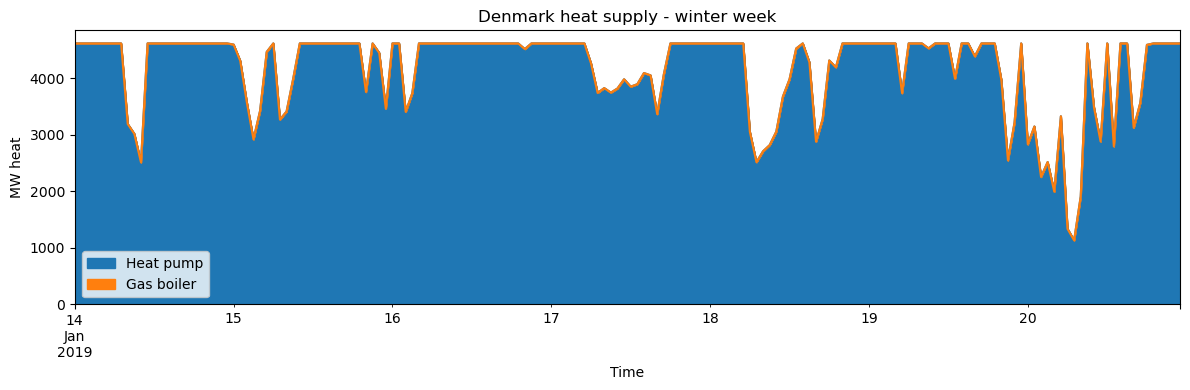

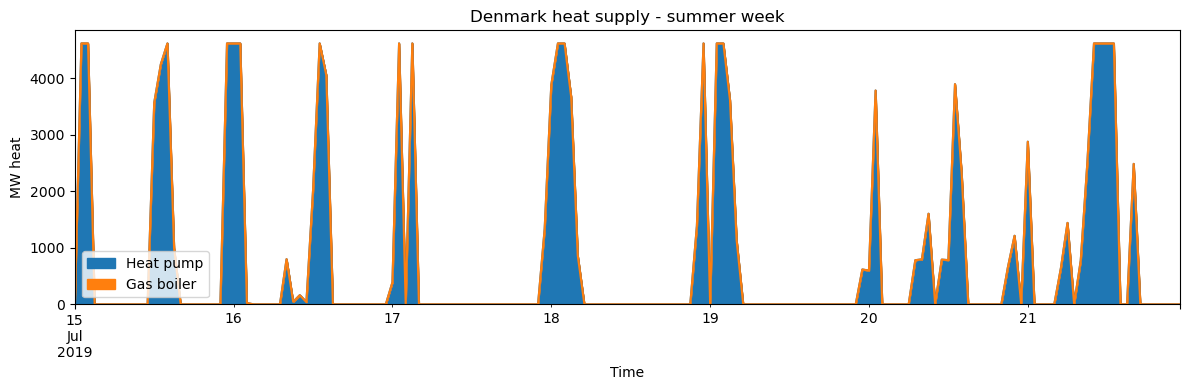

In [22]:
heat_supply = pd.DataFrame({
    "Heat pump": -nd.links_t.p1["DK_heat_pump"],
    "Gas boiler": nd.generators_t.p["DK_gas_boiler"]
})

fig, ax = plt.subplots(figsize=(12, 4))
heat_supply.loc["2019-01-14":"2019-01-20"].plot.area(ax=ax)
ax.set_title("Denmark heat supply - winter week")
ax.set_ylabel("MW heat")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
heat_supply.loc["2019-07-15":"2019-07-21"].plot.area(ax=ax)
ax.set_title("Denmark heat supply - summer week")
ax.set_ylabel("MW heat")
ax.set_xlabel("Time")
plt.tight_layout()
plt.show()